# AA Ticket Workflow — LangGraph

This notebook implements the **Ticket to AA** workflow branch from the multi-workflow agent graph.

## Workflow Summary
```
User Input
  └─► Classify (ticket)
        └─► Validate GPA + Credits
              ├─► [Ineligible] Alert: Requirement Gap → END
              └─► [Eligible] AI Drafts Email + Form
                    └─► Student Approval? (interrupt)
                          ├─► [Edit] loop back to Draft
                          └─► [Approved] Send to Advisor
                                └─► Wait 48h for Reply
                                      ├─► [Timeout] Nudge Advisor (max 3)
                                      │         └─► [Nudges ≥ 3] Escalation Packet → END
                                      └─► [Reply] Extract Intent
                                            ├─► [Approved]  → Registrar Loop
                                            ├─► [Needs Info] AI Search Files/History
                                            │         ├─► [Found]     Draft Response → Student Approval
                                            │         └─► [Not Found] Ask Student   → Student Approval
                                            └─► [Rejected] Notify: Denied → END

Registrar Loop:
  Send to Registrar → Wait 48h
    ├─► [Timeout] Nudge Registrar (max 3) → [≥3] Escalate to Admin → END
    └─► [Reply] Extract Intent
          ├─► [Approved]      Notify: Success 🚀 → END
          └─► [Issue Detected] AI Self-Correct
                ├─► [Fixed]    loop back to Wait 48h
                └─► [Not Fixed] Escalate to Admin → END
```

# 1. Install Dependencies

In [1]:
!pip install -q langchain_core langchain-google-genai langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.0 MB/s eta 0:00:00


In [2]:
!pip install grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.5 MB/s eta 0:00:00


# 2. LLM Setup

In [3]:
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = ""  # <-- paste your key here

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=0.7,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

# 3. State Definition

## AA State

| Field | Type | Purpose |
|---|---|---|
| `messages` | `List[dict]` | Full conversation history |
| `workflow` | `Literal` | Which branch is active |
| `aa_request` | `AARequestData` | Student info (GPA, credits, reason, advisor) |
| `aa_email` | `AAEmailData` | Draft email/form + approval/reply tracking |
| `registrar_email` | `AAEmailData` | Separate tracking for registrar loop |
| `response` | `str` | Latest human-readable output |

In [4]:
from pydantic import BaseModel, Field
from typing import Optional, List, Literal, Annotated


# ──────────────────────────────────────────────
# AA Request data (student academic info)
# ──────────────────────────────────────────────
class AARequestData(BaseModel):
    student_name: Optional[str] = None
    student_id: Optional[str] = None
    gpa: Optional[float] = None
    credits_completed: Optional[int] = None
    reason: Optional[str] = None          # Why they need the AA
    advisor_email: Optional[str] = None
    registrar_email: Optional[str] = None
    is_eligible: Optional[bool] = None
    eligibility_notes: Optional[str] = None


# ──────────────────────────────────────────────
# Email / ticket tracking (reused for both
# advisor loop and registrar loop)
# ──────────────────────────────────────────────
class AAEmailData(BaseModel):
    draft: Optional[str] = None
    approval_status: Optional[
        Literal["pending", "approved", "edit"]
    ] = None
    nudge_count: int = 0
    last_reply: Optional[str] = None
    reply_intent: Optional[
        Literal["approved", "needs_info", "rejected", "issue_detected"]
    ] = None
    status: Optional[Literal["sent", "failed"]] = None
    # For needs_info branch
    search_result: Optional[Literal["found", "not_found"]] = None
    # For self-correct branch
    self_correct_result: Optional[Literal["fixed", "not_fixed"]] = None


# ──────────────────────────────────────────────
# Merge reducer — same pattern as scheduling wf
# ──────────────────────────────────────────────
def merge_aa_email(current: AAEmailData, update: AAEmailData) -> AAEmailData:
    """Merge only explicitly set (non-None) fields; always take max nudge_count."""
    if isinstance(update, dict):
        current_dict = current.model_dump()
        current_dict.update(update)
        return AAEmailData(**current_dict)
    current_dict = current.model_dump()
    update_dict = update.model_dump()
    merged = {**current_dict}
    for k, v in update_dict.items():
        if k == 'nudge_count':
            merged[k] = max(current_dict[k], v)
        elif v is not None:
            merged[k] = v
    return AAEmailData(**merged)


# ──────────────────────────────────────────────
# Top-level agent state
# ──────────────────────────────────────────────
class AgentState(BaseModel):
    messages: List[dict] = Field(default_factory=list)

    workflow: Optional[
        Literal["schedule", "ticket", "chat"]
    ] = None

    # AA-specific state
    aa_request: AARequestData = Field(default_factory=AARequestData)

    # Annotated so the reducer is used automatically by LangGraph
    aa_email: Annotated[AAEmailData, merge_aa_email] = Field(
        default_factory=AAEmailData
    )
    registrar_email: Annotated[AAEmailData, merge_aa_email] = Field(
        default_factory=AAEmailData
    )

    response: Optional[str] = None


print("State classes defined.")

State classes defined.


# 4. Node Definitions

### Node 1: `classify_workflow`
Reads: `messages`  
Writes: `workflow`

In [5]:
from pydantic import BaseModel


class WorkflowOutput(BaseModel):
    workflow: Literal["schedule", "ticket", "chat"]


def classify_workflow(state: AgentState):
    user_input = state.messages[-1]["content"]
    structured_llm = llm.with_structured_output(WorkflowOutput)
    response = structured_llm.invoke([
        {
            "role": "system",
            "content": (
                "Classify the user's request into exactly one of:\n"
                "- schedule (meeting scheduling)\n"
                "- ticket  (academic accommodation / AA request)\n"
                "- chat    (general conversation)\n\n"
                "If uncertain, choose the closest match. Return structured output only."
            ),
        },
        {"role": "user", "content": user_input},
    ])
    print(f"[classify] workflow → {response.workflow}")
    return {"workflow": response.workflow}


print("classify_workflow defined.")

classify_workflow defined.


### Node 2: `extract_aa_info`
Reads: `messages`  
Writes: `aa_request` (student name, ID, GPA, credits, reason, advisor email)

In [6]:
class AAInfoExtraction(BaseModel):
    student_name: Optional[str] = None
    student_id: Optional[str] = None
    gpa: Optional[float] = None
    credits_completed: Optional[int] = None
    reason: Optional[str] = None
    advisor_email: Optional[str] = None
    registrar_email: Optional[str] = None


def extract_aa_info(state: AgentState):
    """Extract student academic info from the user's message."""
    structured_extractor = llm.with_structured_output(AAInfoExtraction)
    result = structured_extractor.invoke([
        {
            "role": "system",
            "content": (
                "Extract academic accommodation (AA) request details from the message.\n"
                "Fields: student_name, student_id, gpa (float), credits_completed (int), "
                "reason for AA, advisor_email, registrar_email.\n"
                "Return None for any field not mentioned."
            ),
        },
        {"role": "user", "content": state.messages[-1]["content"]},
    ])

    # Merge extracted fields onto existing state (don't wipe prior values)
    current = state.aa_request
    updated = AARequestData(
        student_name=result.student_name or current.student_name,
        student_id=result.student_id or current.student_id,
        gpa=result.gpa if result.gpa is not None else current.gpa,
        credits_completed=(
            result.credits_completed
            if result.credits_completed is not None
            else current.credits_completed
        ),
        reason=result.reason or current.reason,
        advisor_email=result.advisor_email or current.advisor_email,
        registrar_email=result.registrar_email or current.registrar_email,
    )
    print(f"[extract_aa_info] student={updated.student_name}, "
          f"gpa={updated.gpa}, credits={updated.credits_completed}")
    return {"aa_request": updated}


print("extract_aa_info defined.")

extract_aa_info defined.


### Node 3: `validate_eligibility`
Reads: `aa_request`  
Writes: `aa_request.is_eligible`, `aa_request.eligibility_notes`

**Eligibility rules (configurable):**
- Minimum GPA: **2.0**
- Minimum credits completed: **30**

In [7]:
MIN_GPA = 2.0
MIN_CREDITS = 30


def validate_eligibility(state: AgentState):
    """Check whether the student meets minimum GPA and credit requirements."""
    req = state.aa_request
    notes = []
    eligible = True

    # GPA check
    if req.gpa is None:
        notes.append("GPA not provided")
        eligible = False
    elif req.gpa < MIN_GPA:
        notes.append(f"GPA {req.gpa} is below minimum {MIN_GPA}")
        eligible = False

    # Credits check
    if req.credits_completed is None:
        notes.append("Credits completed not provided")
        eligible = False
    elif req.credits_completed < MIN_CREDITS:
        notes.append(
            f"Credits {req.credits_completed} below minimum {MIN_CREDITS}"
        )
        eligible = False

    eligibility_notes = "; ".join(notes) if notes else "All requirements met"
    print(f"[validate_eligibility] eligible={eligible}, notes='{eligibility_notes}'")

    updated = AARequestData(
        **req.model_dump(exclude={'is_eligible', 'eligibility_notes'}),
        is_eligible=eligible,
        eligibility_notes=eligibility_notes,
    )
    return {"aa_request": updated}


print("validate_eligibility defined.")

validate_eligibility defined.


### Node 4: `alert_requirement_gap`
Terminal node when student is ineligible.  
Reads: `aa_request.eligibility_notes`  
Writes: `response`

In [8]:
def alert_requirement_gap(state: AgentState):
    """Notify the student they don't meet AA requirements."""
    notes = state.aa_request.eligibility_notes
    msg = (
        f"⚠️  AA Request Ineligible\n"
        f"Unfortunately you do not currently meet the requirements:\n"
        f"  • {notes}\n\n"
        f"Please contact your advisor to discuss options for improving eligibility."
    )
    print(f"[alert_requirement_gap] {msg}")
    return {"response": msg}


print("alert_requirement_gap defined.")

alert_requirement_gap defined.


### Node 5: `draft_aa_email`
AI drafts the email to the advisor AND a summary form.  
Reads: `aa_request`, `messages`  
Writes: `aa_email.draft`, `response`

In [9]:
def draft_aa_email(state: AgentState):
    """Use the LLM to draft a professional AA request email + form summary."""
    req = state.aa_request

    # Build context from any previous conversation
    history_text = "\n".join(
        f"{m['role'].upper()}: {m['content']}" for m in state.messages
    )

    draft = llm.invoke([
        {
            "role": "system",
            "content": (
                "You are an academic assistant helping a student submit an "
                "Academic Accommodation (AA) request.\n"
                "Draft a professional email from the student to their academic advisor "
                "requesting the AA. Also include a brief structured Form Summary at the end.\n"
                "Be concise, polite, and professional."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Student Info:\n"
                f"  Name: {req.student_name or 'N/A'}\n"
                f"  ID: {req.student_id or 'N/A'}\n"
                f"  GPA: {req.gpa}\n"
                f"  Credits Completed: {req.credits_completed}\n"
                f"  Reason for AA Request: {req.reason or 'N/A'}\n"
                f"  Advisor Email: {req.advisor_email or 'N/A'}\n\n"
                f"Conversation Context:\n{history_text}"
            ),
        },
    ])

    # Ensure draft_text is a string, handling cases where draft.content might be a list of parts
    if isinstance(draft.content, list):
        draft_text = "".join([part["text"] for part in draft.content if part.get("text")])
    else:
        draft_text = draft.content

    print(f"[draft_aa_email] draft generated ({len(draft_text)} chars)")
    return {
        "aa_email": AAEmailData(draft=draft_text),
        "response": draft_text,
    }


### Node 6: `process_student_approval`  (interrupt)
Shows the draft to the student and waits for their decision.  
Reads: `aa_email.draft`  
Writes: `aa_email.approval_status`

In [10]:
from langgraph.types import interrupt


def process_student_approval(state: AgentState):
    """Interrupt to show draft email to student and capture approval."""
    user_input = interrupt({
        "email_draft": state.aa_email.draft,
        "message": "Please review the draft AA request email above. Type: approved / edit",
    })

    content = user_input["content"].lower()
    if any(w in content for w in ["approved", "ok", "looks good", "send it", "yes"]):
        status = "approved"
    elif "edit" in content or "change" in content or "update" in content:
        status = "edit"
    else:
        status = "pending"

    print(f"[process_student_approval] student said: '{content}' → status={status}")
    return {"aa_email": AAEmailData(approval_status=status)}


print("process_student_approval defined.")

process_student_approval defined.


### Node 7: `send_to_advisor`
Reads: `aa_email.draft`, `aa_request.advisor_email`  
Writes: `aa_email.status`, `response`

In [11]:
def send_to_advisor(state: AgentState):
    """Placeholder: send the approved AA email to the advisor."""
    advisor = state.aa_request.advisor_email or "advisor@university.edu"
    print(f"[send_to_advisor] === PLACEHOLDER: email sent to {advisor} ===")
    print(f"  Draft:\n{state.aa_email.draft}")
    return {
        "aa_email": AAEmailData(status="sent"),
        "response": f"AA request email sent to advisor ({advisor}).",
    }


print("send_to_advisor defined.")

send_to_advisor defined.


### Node 8: `wait_for_advisor_reply`
Reads: *(nothing new)*  
Writes: `aa_email.last_reply`

> **Production note:** In a real system this node would pause the graph (e.g. using a durable sleep / webhook trigger). Here we simulate no reply by default.

In [12]:
def wait_for_advisor_reply(state: AgentState):
    """Placeholder: simulate waiting 48h for advisor reply. No reply received."""
    print("[wait_for_advisor_reply] === PLACEHOLDER: simulating 48h wait — no reply ===")
    return {"aa_email": AAEmailData(last_reply=None)}


print("wait_for_advisor_reply defined.")

wait_for_advisor_reply defined.


### Node 9: `nudge_advisor`
Reads: `aa_email.nudge_count`  
Writes: `aa_email.nudge_count`, `response`

In [13]:
def nudge_advisor(state: AgentState):
    """Send a polite follow-up nudge to the advisor."""
    new_count = state.aa_email.nudge_count + 1
    nudge_text = (
        f"Subject: Follow-up: AA Request (Nudge #{new_count})\n\n"
        f"Dear Advisor,\n\n"
        f"I wanted to follow up on my Academic Accommodation request sent earlier.\n"
        f"Could you please review it at your earliest convenience?\n\n"
        f"Thank you,\n"
        f"{state.aa_request.student_name or 'Student'}"
    )
    print(f"[nudge_advisor] === PLACEHOLDER: nudge #{new_count} sent to advisor ===")
    return {
        "aa_email": AAEmailData(nudge_count=new_count, draft=nudge_text),
        "response": nudge_text,
    }


print("nudge_advisor defined.")

nudge_advisor defined.


### Node 10: `send_escalation_packet`
Terminal node when advisor is unresponsive after max nudges.  
Reads: `aa_request`, `aa_email`  
Writes: `response`

In [14]:
def send_escalation_packet(state: AgentState):
    """Compile and send an escalation packet to the department/dean."""
    msg = (
        f"📦 Escalation Packet Generated\n"
        f"Student: {state.aa_request.student_name or 'N/A'} "
        f"(ID: {state.aa_request.student_id or 'N/A'})\n"
        f"Reason: Advisor did not respond after "
        f"{state.aa_email.nudge_count} nudge(s).\n"
        f"Action: Packet forwarded to Department Chair / Dean's office for review."
    )
    print(f"[send_escalation_packet] === PLACEHOLDER: {msg} ===")
    return {"response": msg}


print("send_escalation_packet defined.")

send_escalation_packet defined.


### Node 11: `extract_advisor_intent`
Reads: `aa_email.last_reply`  
Writes: `aa_email.reply_intent`

In [15]:
class AdvisorIntentOutput(BaseModel):
    reply_intent: Literal["approved", "needs_info", "rejected"]


def extract_advisor_intent(state: AgentState):
    """Classify the advisor's reply intent."""
    reply = state.aa_email.last_reply
    if not reply:
        return {}

    structured_parser = llm.with_structured_output(AdvisorIntentOutput)
    result = structured_parser.invoke([
        {
            "role": "system",
            "content": (
                "You are classifying an advisor's reply to an Academic Accommodation request.\n"
                "Classify as one of:\n"
                "- approved    (advisor approves the AA request)\n"
                "- needs_info  (advisor needs more information before deciding)\n"
                "- rejected    (advisor denies the AA request)\n"
                "Return structured output only."
            ),
        },
        {"role": "user", "content": reply},
    ])
    print(f"[extract_advisor_intent] reply_intent={result.reply_intent}")
    return {"aa_email": AAEmailData(reply_intent=result.reply_intent)}


print("extract_advisor_intent defined.")

extract_advisor_intent defined.


### Node 12: `search_files_history`
When the advisor needs more info, AI searches the student's documents/history.  
Reads: `aa_request`, `aa_email`  
Writes: `aa_email.search_result`, `response`

In [16]:
def search_files_history(state: AgentState):
    """
    Placeholder: AI searches student files / conversation history for
    information the advisor is asking for.

    In production: integrate with a document store (e.g. Google Drive,
    university portal) and use RAG / tool-calling to retrieve relevant docs.
    """
    print("[search_files_history] === PLACEHOLDER: searching student files/history ===")

    # Simulate: 50% chance we find something (toggle for testing)
    # To test the 'not_found' branch, set found = False
    found = True  # <-- change to False to test the ask_student branch

    if found:
        found_text = (
            "Found relevant document: 'Medical Certificate - Spring 2024.pdf'\n"
            "This document supports the student's AA request."
        )
        print(f"[search_files_history] found relevant document")
        return {
            "aa_email": AAEmailData(search_result="found"),
            "response": found_text,
        }
    else:
        print(f"[search_files_history] no relevant document found")
        return {
            "aa_email": AAEmailData(search_result="not_found"),
            "response": "No supporting documents found in the student's history.",
        }


print("search_files_history defined.")

search_files_history defined.


### Node 13: `draft_info_response`
When files were found, AI drafts a supplementary response to the advisor.  
Reads: `aa_email`, `aa_request`  
Writes: `aa_email.draft`, `response`

In [17]:
def draft_info_response(state: AgentState):
    """Draft a supplementary response to the advisor using found documents."""
    req = state.aa_request

    draft = llm.invoke([
        {
            "role": "system",
            "content": (
                "You are an academic assistant. The advisor asked for more information "
                "about the student's AA request. Supporting documents have been found.\n"
                "Draft a concise follow-up email from the student to the advisor, "
                "referencing the supporting document found."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Student: {req.student_name or 'N/A'} (ID: {req.student_id or 'N/A'})\n"
                f"Supporting doc found: {state.response}\n"
                f"Advisor's last reply: {state.aa_email.last_reply}"
            ),
        },
    ])

    draft_text = draft.content
    print(f"[draft_info_response] supplementary draft generated")
    return {
        "aa_email": AAEmailData(
            draft=draft_text,
            # Reset approval so student reviews the new draft
            approval_status=None,
            # Reset search_result so routing doesn't loop
            search_result=None,
            reply_intent=None,
        ),
        "response": draft_text,
    }


print("draft_info_response defined.")

draft_info_response defined.


### Node 14: `ask_student_for_info`
When no files found, interrupt to ask the student directly.  
Reads: `aa_email.last_reply`  
Writes: `messages`, `aa_email.draft`, `response`

In [18]:
def ask_student_for_info(state: AgentState):
    """Interrupt: ask the student to provide the additional info the advisor needs."""
    question = (
        "The advisor requires additional information to process your AA request.\n"
        f"Advisor's message: '{state.aa_email.last_reply}'\n\n"
        "Please provide the requested information so I can update the email."
    )
    user_reply = interrupt({"message": question})

    # Append student's reply so draft_info_response can use it
    updated_messages = state.messages + [user_reply]

    # Draft a quick holding response
    draft_text = (
        f"Subject: Re: AA Request — Additional Information\n\n"
        f"Dear Advisor,\n\n"
        f"Thank you for your response. Please see the additional information below:\n\n"
        f"{user_reply['content']}\n\n"
        f"Best regards,\n"
        f"{state.aa_request.student_name or 'Student'}"
    )

    print(f"[ask_student_for_info] student provided info")
    return {
        "messages": updated_messages,
        "aa_email": AAEmailData(
            draft=draft_text,
            approval_status=None,
            search_result=None,
            reply_intent=None,
        ),
        "response": question,
    }


print("ask_student_for_info defined.")

ask_student_for_info defined.


### Node 15: `notify_aa_denied`
Terminal node when advisor rejects the AA.  
Reads: `aa_request`  
Writes: `response`

In [19]:
def notify_aa_denied(state: AgentState):
    """Notify student that the advisor denied the AA request."""
    msg = (
        f"❌  AA Request Denied\n"
        f"Your Academic Accommodation request has been reviewed and denied "
        f"by your advisor.\n"
        f"If you believe this decision is incorrect, you may appeal through "
        f"the Dean of Students office."
    )
    print(f"[notify_aa_denied] {msg}")
    return {"response": msg}


print("notify_aa_denied defined.")

notify_aa_denied defined.


---
## Registrar Loop Nodes

Once the advisor approves, the request is forwarded to the Registrar.

### Node 16: `forward_to_registrar`
Reads: `aa_email.draft`, `aa_request.registrar_email`  
Writes: `registrar_email.status`, `response`

In [20]:
def forward_to_registrar(state: AgentState):
    """Placeholder: forward the approved AA to the registrar."""
    registrar = state.aa_request.registrar_email or "registrar@university.edu"
    print(f"[forward_to_registrar] === PLACEHOLDER: forwarded to {registrar} ===")
    return {
        "registrar_email": AAEmailData(status="sent"),
        "response": f"AA request forwarded to registrar ({registrar}) for final processing.",
    }


print("forward_to_registrar defined.")

forward_to_registrar defined.


### Node 17: `wait_for_registrar_reply`
Reads: *(nothing new)*  
Writes: `registrar_email.last_reply`

In [21]:
def wait_for_registrar_reply(state: AgentState):
    """Placeholder: simulate 48h wait for registrar reply."""
    print("[wait_for_registrar_reply] === PLACEHOLDER: simulating 48h wait — no reply ===")
    return {"registrar_email": AAEmailData(last_reply=None)}


print("wait_for_registrar_reply defined.")

wait_for_registrar_reply defined.


### Node 18: `nudge_registrar`
Reads: `registrar_email.nudge_count`  
Writes: `registrar_email.nudge_count`, `response`

In [22]:
def nudge_registrar(state: AgentState):
    """Send a follow-up nudge to the registrar."""
    new_count = state.registrar_email.nudge_count + 1
    nudge_text = (
        f"Subject: Follow-up: AA Processing Request (Nudge #{new_count})\n\n"
        f"Dear Registrar,\n\n"
        f"I am following up on the Academic Accommodation request forwarded to "
        f"your office. Could you please provide an update?\n\n"
        f"Thank you,\n"
        f"{state.aa_request.student_name or 'Student'}"
    )
    print(f"[nudge_registrar] === PLACEHOLDER: registrar nudge #{new_count} sent ===")
    return {
        "registrar_email": AAEmailData(nudge_count=new_count, draft=nudge_text),
        "response": nudge_text,
    }


print("nudge_registrar defined.")

nudge_registrar defined.


### Node 19: `escalate_to_admin`
Terminal node when registrar is unresponsive or issue cannot be fixed.  
Reads: `aa_request`  
Writes: `response`

In [23]:
def escalate_to_admin(state: AgentState):
    """Escalate the AA request to university administration."""
    msg = (
        f"🚨 Escalated to Admin\n"
        f"Student: {state.aa_request.student_name or 'N/A'} "
        f"(ID: {state.aa_request.student_id or 'N/A'})\n"
        f"The AA request has been escalated to the university administration "
        f"due to an unresolved issue with the registrar's office.\n"
        f"A case manager will contact you within 3 business days."
    )
    print(f"[escalate_to_admin] === PLACEHOLDER: {msg} ===")
    return {"response": msg}


print("escalate_to_admin defined.")

escalate_to_admin defined.


### Node 20: `extract_registrar_intent`
Reads: `registrar_email.last_reply`  
Writes: `registrar_email.reply_intent`

In [24]:
class RegistrarIntentOutput(BaseModel):
    reply_intent: Literal["approved", "issue_detected"]


def extract_registrar_intent(state: AgentState):
    """Classify the registrar's reply: approved or issue_detected."""
    reply = state.registrar_email.last_reply
    if not reply:
        return {}

    structured_parser = llm.with_structured_output(RegistrarIntentOutput)
    result = structured_parser.invoke([
        {
            "role": "system",
            "content": (
                "You are classifying a registrar's reply to an Academic Accommodation request.\n"
                "Classify as one of:\n"
                "- approved        (registrar fully processes and approves the request)\n"
                "- issue_detected  (registrar found a problem, error, or missing item)\n"
                "Return structured output only."
            ),
        },
        {"role": "user", "content": reply},
    ])
    print(f"[extract_registrar_intent] reply_intent={result.reply_intent}")
    return {"registrar_email": AAEmailData(reply_intent=result.reply_intent)}


print("extract_registrar_intent defined.")

extract_registrar_intent defined.


### Node 21: `notify_aa_success`
Terminal success node.  
Reads: `aa_request`  
Writes: `response`

In [25]:
def notify_aa_success(state: AgentState):
    """Notify student that their AA request was fully approved."""
    msg = (
        f"🚀 AA Request Approved!\n"
        f"Congratulations {state.aa_request.student_name or 'Student'}!\n"
        f"Your Academic Accommodation request has been approved by both "
        f"your advisor and the registrar's office.\n"
        f"Your accommodations are now officially in effect."
    )
    print(f"[notify_aa_success] {msg}")
    return {"response": msg}


print("notify_aa_success defined.")

notify_aa_success defined.


### Node 22: `ai_self_correct`
When registrar finds an issue, AI attempts to self-correct the request.  
Reads: `registrar_email.last_reply`, `aa_request`, `aa_email`  
Writes: `registrar_email.self_correct_result`, `aa_email.draft`, `response`

In [26]:
def ai_self_correct(state: AgentState):
    """
    AI attempts to fix the issue identified by the registrar.

    In production: parse the registrar's issue, cross-reference the original
    submission, and generate a corrected version.

    Here we simulate: always 'fixed' for the happy path.
    Toggle `fixed = False` to test the escalation branch.
    """
    print("[ai_self_correct] === PLACEHOLDER: AI attempting to fix registrar issue ===")

    # Simulate fix attempt
    fixed = True  # <-- set to False to test escalation path

    if fixed:
        corrected_draft = (
            f"Subject: Corrected AA Submission\n\n"
            f"Dear Registrar,\n\n"
            f"Thank you for flagging the issue. Please find the corrected "
            f"Academic Accommodation request attached.\n"
            f"The issue has been resolved: "
            f"{state.registrar_email.last_reply or 'see corrections below'}.\n\n"
            f"Best regards,\n"
            f"{state.aa_request.student_name or 'Student'}"
        )
        print("[ai_self_correct] fix successful")
        return {
            "registrar_email": AAEmailData(
                self_correct_result="fixed",
                reply_intent=None,   # reset so the loop continues
                last_reply=None,
            ),
            "aa_email": AAEmailData(draft=corrected_draft),
            "response": corrected_draft,
        }
    else:
        print("[ai_self_correct] could not fix — escalating")
        return {
            "registrar_email": AAEmailData(self_correct_result="not_fixed"),
            "response": "AI could not automatically resolve the registrar's issue.",
        }


print("ai_self_correct defined.")

ai_self_correct defined.


# 5. Build the Graph

### 5a. Register All Nodes

In [27]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(AgentState)

# ── Shared ──────────────────────────────────
builder.add_node("classify",                classify_workflow)

# ── AA Workflow ──────────────────────────────
builder.add_node("extract_aa_info",         extract_aa_info)
builder.add_node("validate_eligibility",    validate_eligibility)
builder.add_node("alert_requirement_gap",   alert_requirement_gap)
builder.add_node("draft_aa_email",          draft_aa_email)
builder.add_node("process_student_approval",process_student_approval)
builder.add_node("send_to_advisor",         send_to_advisor)
builder.add_node("wait_for_advisor_reply",  wait_for_advisor_reply)
builder.add_node("nudge_advisor",           nudge_advisor)
builder.add_node("send_escalation_packet",  send_escalation_packet)
builder.add_node("extract_advisor_intent",  extract_advisor_intent)
builder.add_node("search_files_history",    search_files_history)
builder.add_node("draft_info_response",     draft_info_response)
builder.add_node("ask_student_for_info",    ask_student_for_info)
builder.add_node("notify_aa_denied",        notify_aa_denied)

# ── Registrar Loop ───────────────────────────
builder.add_node("forward_to_registrar",    forward_to_registrar)
builder.add_node("wait_for_registrar_reply",wait_for_registrar_reply)
builder.add_node("nudge_registrar",         nudge_registrar)
builder.add_node("escalate_to_admin",       escalate_to_admin)
builder.add_node("extract_registrar_intent",extract_registrar_intent)
builder.add_node("notify_aa_success",       notify_aa_success)
builder.add_node("ai_self_correct",         ai_self_correct)

builder.set_entry_point("classify")
print("All nodes registered.")

All nodes registered.


### 5b. Edges & Conditional Routing

In [28]:
# ── Entry ────────────────────────────────────
builder.add_edge(START, "classify")


# ── Route after classify ─────────────────────
def route_workflow(state: AgentState):
    if state.workflow == "ticket":
        return "extract_aa_info"
    # schedule / chat branches not implemented here — return END
    return END


builder.add_conditional_edges(
    "classify",
    route_workflow,
    {"extract_aa_info": "extract_aa_info", END: END},
)


# ── AA info → validate ────────────────────────
builder.add_edge("extract_aa_info", "validate_eligibility")


# ── Route after eligibility check ────────────
def route_eligibility(state: AgentState):
    if state.aa_request.is_eligible:
        return "draft_aa_email"
    return "alert_requirement_gap"


builder.add_conditional_edges(
    "validate_eligibility",
    route_eligibility,
    {"draft_aa_email": "draft_aa_email", "alert_requirement_gap": "alert_requirement_gap"},
)

builder.add_edge("alert_requirement_gap", END)


# ── Draft → student approval ─────────────────
builder.add_edge("draft_aa_email", "process_student_approval")


# ── Route after student approval ─────────────
def route_student_approval(state: AgentState):
    if state.aa_email.approval_status == "approved":
        return "send_to_advisor"
    # edit or pending → redraft
    return "draft_aa_email"


builder.add_conditional_edges(
    "process_student_approval",
    route_student_approval,
    {"send_to_advisor": "send_to_advisor", "draft_aa_email": "draft_aa_email"},
)


# ── Send to advisor → wait ────────────────────
builder.add_edge("send_to_advisor", "wait_for_advisor_reply")


# ── Route after waiting for advisor ──────────
MAX_ADVISOR_NUDGES = 3


def route_advisor_reply(state: AgentState):
    if state.aa_email.last_reply:
        return "extract_advisor_intent"
    # Timeout path
    if state.aa_email.nudge_count < MAX_ADVISOR_NUDGES:
        return "nudge_advisor"
    return "send_escalation_packet"


builder.add_conditional_edges(
    "wait_for_advisor_reply",
    route_advisor_reply,
    {
        "extract_advisor_intent": "extract_advisor_intent",
        "nudge_advisor": "nudge_advisor",
        "send_escalation_packet": "send_escalation_packet",
    },
)

builder.add_edge("nudge_advisor", "wait_for_advisor_reply")
builder.add_edge("send_escalation_packet", END)


# ── Route advisor intent ──────────────────────
def route_advisor_intent(state: AgentState):
    intent = state.aa_email.reply_intent
    if intent == "approved":
        return "forward_to_registrar"
    elif intent == "needs_info":
        return "search_files_history"
    elif intent == "rejected":
        return "notify_aa_denied"
    # Fallback
    return "notify_aa_denied"


builder.add_conditional_edges(
    "extract_advisor_intent",
    route_advisor_intent,
    {
        "forward_to_registrar": "forward_to_registrar",
        "search_files_history": "search_files_history",
        "notify_aa_denied": "notify_aa_denied",
    },
)

builder.add_edge("notify_aa_denied", END)


# ── Search files → draft or ask student ──────
def route_search_result(state: AgentState):
    if state.aa_email.search_result == "found":
        return "draft_info_response"
    return "ask_student_for_info"


builder.add_conditional_edges(
    "search_files_history",
    route_search_result,
    {
        "draft_info_response": "draft_info_response",
        "ask_student_for_info": "ask_student_for_info",
    },
)

# Both paths lead back to student approval for the updated draft
builder.add_edge("draft_info_response",  "process_student_approval")
builder.add_edge("ask_student_for_info", "process_student_approval")


# ── Registrar loop ────────────────────────────
builder.add_edge("forward_to_registrar", "wait_for_registrar_reply")

MAX_REGISTRAR_NUDGES = 3


def route_registrar_reply(state: AgentState):
    if state.registrar_email.last_reply:
        return "extract_registrar_intent"
    if state.registrar_email.nudge_count < MAX_REGISTRAR_NUDGES:
        return "nudge_registrar"
    return "escalate_to_admin"


builder.add_conditional_edges(
    "wait_for_registrar_reply",
    route_registrar_reply,
    {
        "extract_registrar_intent": "extract_registrar_intent",
        "nudge_registrar": "nudge_registrar",
        "escalate_to_admin": "escalate_to_admin",
    },
)

builder.add_edge("nudge_registrar", "wait_for_registrar_reply")
builder.add_edge("escalate_to_admin", END)


# ── Route registrar intent ────────────────────
def route_registrar_intent(state: AgentState):
    intent = state.registrar_email.reply_intent
    if intent == "approved":
        return "notify_aa_success"
    elif intent == "issue_detected":
        return "ai_self_correct"
    return "escalate_to_admin"


builder.add_conditional_edges(
    "extract_registrar_intent",
    route_registrar_intent,
    {
        "notify_aa_success": "notify_aa_success",
        "ai_self_correct": "ai_self_correct",
        "escalate_to_admin": "escalate_to_admin",
    },
)

builder.add_edge("notify_aa_success", END)


# ── Self-correct branch ───────────────────────
def route_self_correct(state: AgentState):
    if state.registrar_email.self_correct_result == "fixed":
        # Re-enter the registrar wait loop with the corrected submission
        return "wait_for_registrar_reply"
    return "escalate_to_admin"


builder.add_conditional_edges(
    "ai_self_correct",
    route_self_correct,
    {
        "wait_for_registrar_reply": "wait_for_registrar_reply",
        "escalate_to_admin": "escalate_to_admin",
    },
)

print("All edges defined.")

All edges defined.


### 5c. Compile the Graph

Graph compiled successfully.


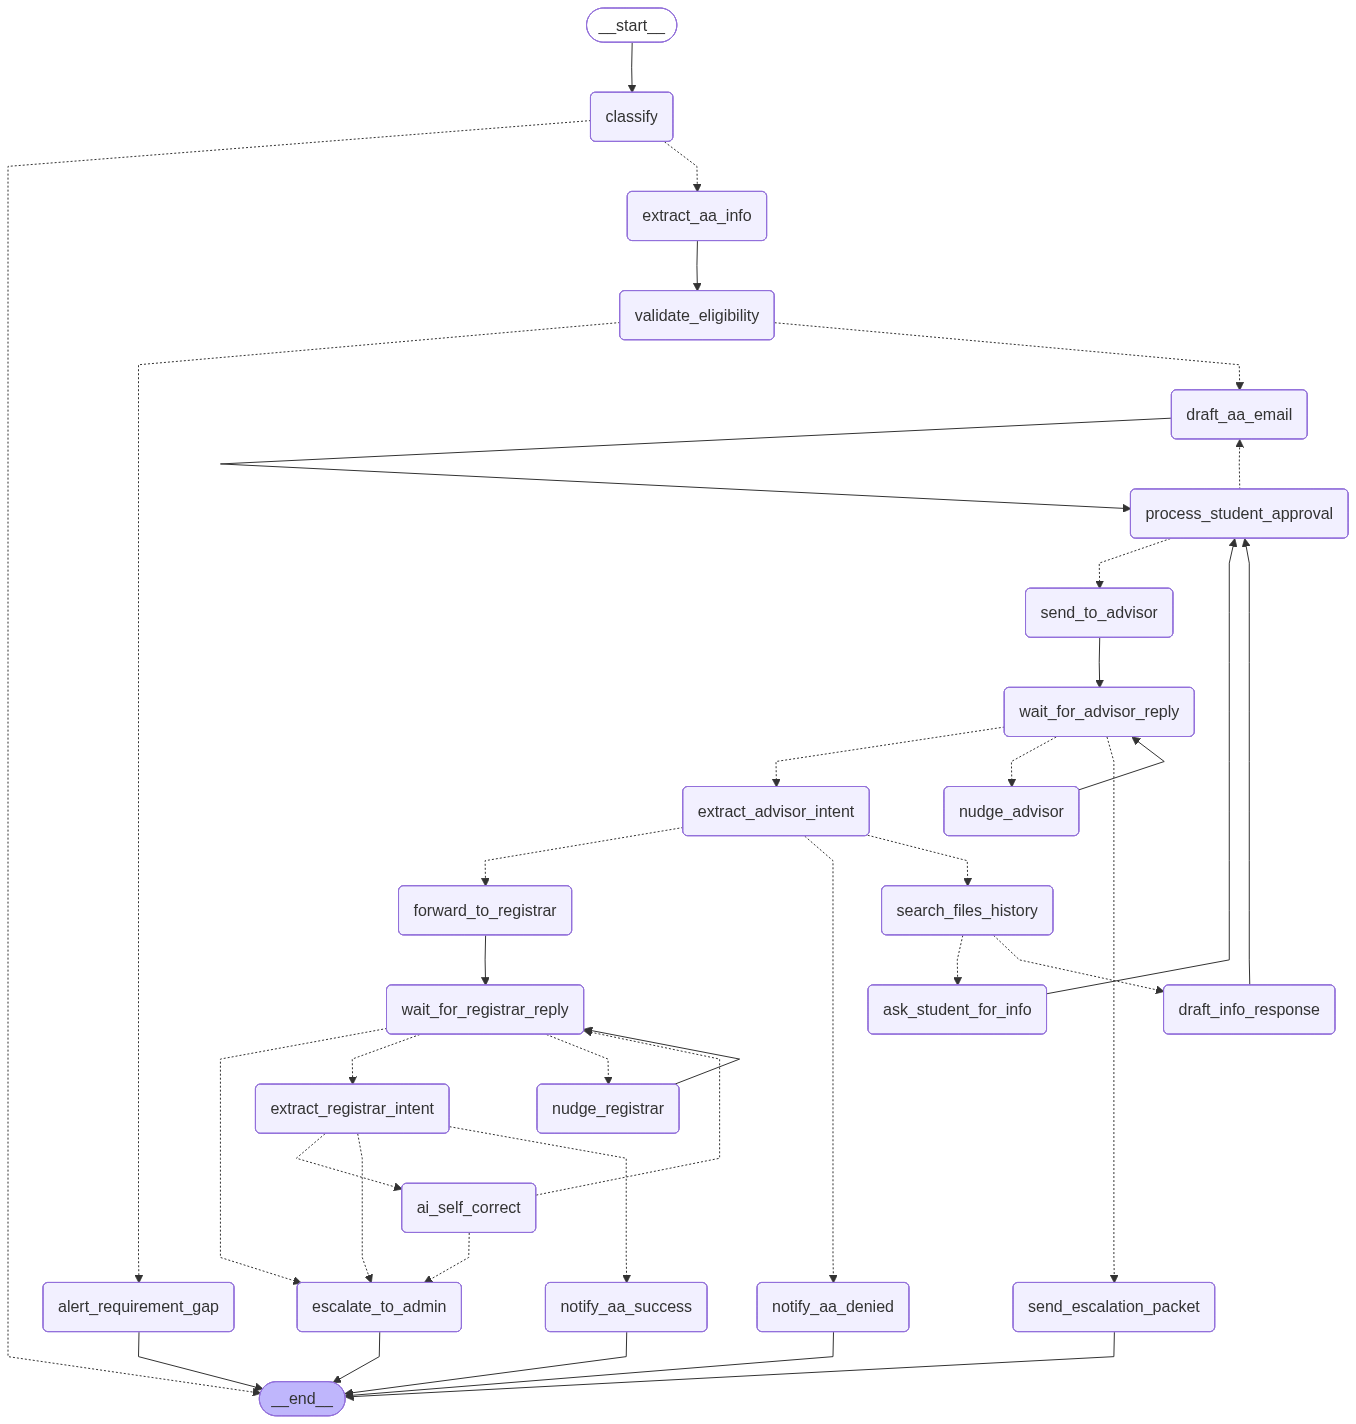

In [29]:
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
print("Graph compiled successfully.")

from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

# 6. Run the Workflow

## Test Case: Eligible student requesting AA

Change `gpa` and `credits_completed` to test the ineligible branch.

In [30]:
from langgraph.types import Command

initial_state = AgentState(
    messages=[
        {
            "role": "user",
            "content": (
                "I need to submit an Academic Accommodation request. "
                "My name is Nguyen Van A, student ID 220123. "
                "My GPA is 3.2 and I have completed 65 credits. "
                "I need the accommodation due to a medical condition diagnosed this semester. "
                "My advisor email is advisor.tran@student.fulbright.eud.vn and "
                "registrar email is registrar@fulbright.edu.vn"
            ),
        }
    ],
    aa_request=AARequestData(),
    aa_email=AAEmailData(),
    registrar_email=AAEmailData(),
)

config = {
    "configurable": {"thread_id": "aa-test-1"},
    "recursion_limit": 40,
}

result = graph.invoke(initial_state, config=config)
print("\n=== INITIAL RUN RESULT ===")
print(result)

# ── Handle interrupt loop ─────────────────────
while "__interrupt__" in result:
    print("\n--- INTERRUPTED ---")
    interrupt_data = result["__interrupt__"][0].value
    print("Message:", interrupt_data.get("message", ""))

    if "email_draft" in interrupt_data:
        print("\nDraft Email:")
        print(interrupt_data["email_draft"])
        prompt = "Type: approved / edit: "
    else:
        prompt = "Your reply: "

    user_input_string = str(input(prompt))
    user_decision_message = {"role": "user", "content": user_input_string}

    result = graph.invoke(
        Command(resume=user_decision_message),
        config=config,
    )
    print("\n=== AFTER RESUME ===")
    print(result)

[classify] workflow → ticket
[extract_aa_info] student=Nguyen Van A, gpa=3.2, credits=65
[validate_eligibility] eligible=True, notes='All requirements met'
[draft_aa_email] draft generated (1073 chars)

=== INITIAL RUN RESULT ===
{'messages': [{'role': 'user', 'content': 'I need to submit an Academic Accommodation request. My name is Nguyen Van A, student ID 220123. My GPA is 3.2 and I have completed 65 credits. I need the accommodation due to a medical condition diagnosed this semester. My advisor email is advisor.tran@student.fulbright.eud.vn and registrar email is registrar@fulbright.edu.vn'}], 'workflow': 'ticket', 'aa_request': AARequestData(student_name='Nguyen Van A', student_id='220123', gpa=3.2, credits_completed=65, reason='medical condition diagnosed this semester', advisor_email='advisor.tran@student.fulbright.eud.vn', registrar_email='registrar@fulbright.edu.vn', is_eligible=True, eligibility_notes='All requirements met'), 'aa_email': AAEmailData(draft='Subject: Academic A

[process_student_approval] student said: 'approved' → status=approved
[send_to_advisor] === PLACEHOLDER: email sent to advisor.tran@student.fulbright.eud.vn ===
  Draft:
Subject: Academic Accommodation Request - Nguyen Van A (ID: 220123)

Dear Advisor Tran,

I am writing to formally request Academic Accommodations for the current semester. I was recently diagnosed with a medical condition that I believe may impact my academic performance and my ability to meet certain course requirements.

I am currently in the process of gathering the necessary medical documentation to submit to the Registrar’s Office. I would appreciate your guidance on any specific departmental procedures I should follow to ensure my academic progress remains on track while I manage this condition.

Thank you for your time and support. I look forward to hearing from you.

Best regards,

Nguyen Van A
Student ID: 220123

***

### **Form Summary**

*   **Student Name:** Nguyen Van A
*   **Student ID:** 220123
*   **Cur

## Test Case: Ineligible student (low GPA)

This path should hit `alert_requirement_gap` and end immediately.

In [31]:
initial_state_ineligible = AgentState(
    messages=[
        {
            "role": "user",
            "content": (
                "I want to apply for an Academic Accommodation. "
                "My name is Le Thi B, student ID 220456. "
                "My GPA is 1.5 and I have completed 20 credits. "
                "I need accommodation due to family circumstances."
            ),
        }
    ],
    aa_request=AARequestData(),
    aa_email=AAEmailData(),
    registrar_email=AAEmailData(),
)

config_ineligible = {
    "configurable": {"thread_id": "aa-test-ineligible"},
    "recursion_limit": 20,
}

result_ineligible = graph.invoke(initial_state_ineligible, config=config_ineligible)
print("\n=== INELIGIBLE CASE RESULT ===")
print("Final response:", result_ineligible.get("response"))

[classify] workflow → ticket
[extract_aa_info] student=Le Thi B, gpa=1.5, credits=20
[validate_eligibility] eligible=False, notes='GPA 1.5 is below minimum 2.0; Credits 20 below minimum 30'
[alert_requirement_gap] ⚠️  AA Request Ineligible
Unfortunately you do not currently meet the requirements:
  • GPA 1.5 is below minimum 2.0; Credits 20 below minimum 30

Please contact your advisor to discuss options for improving eligibility.

=== INELIGIBLE CASE RESULT ===
Final response: ⚠️  AA Request Ineligible
Unfortunately you do not currently meet the requirements:
  • GPA 1.5 is below minimum 2.0; Credits 20 below minimum 30

Please contact your advisor to discuss options for improving eligibility.
